<a href="https://colab.research.google.com/github/vamsiram89/ML-Projects/blob/ML/Power_Plant_Energy_Output_Prediction_using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Main Objective:-**

**To predict the electrical power output of a power plant using environmental conditions.**







**This model predicts:**

**@PE (Power Energy Output)**

**-->This is the net hourly electrical energy output of the power plant (in MW).**

**-->Input Variables (Features)**

**Used 4 environmental variables:**

**Feature	Meaning	Affects**


**Dataset Features**

| Feature | Description | Affects |
|--------|-------------|--------|
| AT | Ambient Temperature | Gas Turbine performance |
| V | Exhaust Vacuum | Steam Turbine performance |
| AP | Ambient Pressure | Gas Turbine performance |
| RH | Relative Humidity | Gas Turbine performance |



## Real-World Importance of the Project

Predicting the electrical power output of a Combined Cycle Power Plant is very important in real-world energy management. Power plants must continuously monitor environmental conditions to estimate how much electricity they will generate.

### Why This Prediction is Important

Power plants use these predictions to:

- **Predict electricity generation:** Estimate how much electrical power will be produced under specific environmental conditions.
- **Optimize plant efficiency:** Adjust operational parameters to achieve maximum efficiency of gas turbines and steam turbines.
- **Plan energy distribution:** Help electricity grid operators distribute power effectively to meet demand.
- **Reduce energy loss:** Identify inefficiencies and reduce unnecessary energy waste.

### Traditional Approach (Without Machine Learning)

Traditionally, engineers calculate power output using complex **thermodynamic and physical equations**. These calculations require deep domain knowledge and can be time-consuming when dealing with large amounts of data.

### Machine Learning Approach

Using **Machine Learning models such as Linear Regression**, we can build a predictive system that learns from historical plant data. The model can quickly estimate the power output based on environmental variables like:

- Ambient Temperature (AT)
- Exhaust Vacuum (V)
- Ambient Pressure (AP)
- Relative Humidity (RH)

This approach enables faster predictions, supports data-driven decision making, and helps power plants operate more efficiently.

**import libararies**

In [ ]:
import pandas as pd
import numpy as np

**Import dataset**

In [ ]:
data_df = pd.read_csv("/content/sample_data/combined_cycle_power_plant.csv")

In [ ]:
data_df

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
...,...,...,...,...,...
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74


**Define x and y**

In [ ]:
x = data_df.drop(['PE'],axis =1).values
y = data_df['PE'].values

In [ ]:
# independent variable
print(x)

[[  14.96   41.76 1024.07   73.17]
 [  25.18   62.96 1020.04   59.08]
 [   5.11   39.4  1012.16   92.14]
 ...
 [  31.32   74.33 1012.92   36.48]
 [  24.48   69.45 1013.86   62.39]
 [  21.6    62.52 1017.23   67.87]]


In [ ]:
# dependent variable
print(y)

[463.26 444.37 488.56 ... 429.57 435.74 453.28]


**split the dataset in training set and testing set**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state =0)

**Train the model on the training set**

In [ ]:
from sklearn.linear_model import LinearRegression
ml_regressor = LinearRegression()
ml_regressor.fit(x_train,y_train)


LinearRegression()

**predict the test set results**

In [ ]:
y_predict = ml_regressor.predict(x_test)
print(y_predict)

[431.40245096 458.61474119 462.81967423 ... 432.47380825 436.16417243
 439.00714594]


In [ ]:
ml_regressor.predict([[14.96,41.76,1024.07,73.17]])


array([467.34820092])

**Evaluate the model**

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test,y_predict)


0.9304112159477683

**Plot the results**

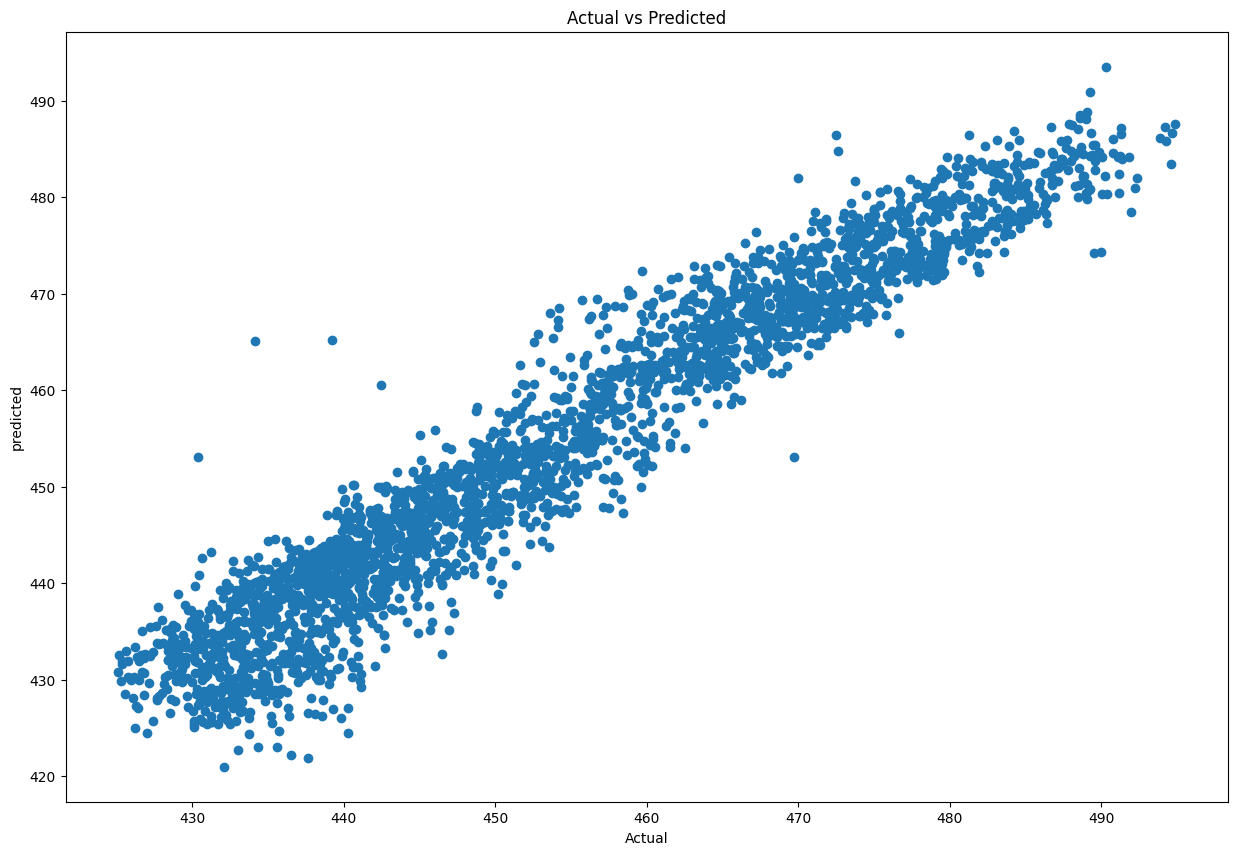

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.scatter(y_test,y_predict)
plt.xlabel("Actual")
plt.ylabel("predicted")
plt.title("Actual vs Predicted")
plt.show()

**Predicted values**

In [ ]:
pred_y_df = pd.DataFrame({'Actual value':y_test,'Predicted value':y_predict,'Difference':y_test-y_predict})
pred_y_df[0:20]



,Actual value,Predicted value,Difference
0,431.23,431.402451,-0.172451
1,460.01,458.614741,1.395259
2,461.14,462.819674,-1.679674
3,445.90,448.601237,-2.701237
4,451.29,457.879479,-6.589479
5,432.68,429.676856,3.003144
6,477.50,473.017115,4.482885
7,459.68,456.532373,3.147627
8,477.50,474.342524,3.157476
9,444.99,446.364396,-1.374396
